## Logistic Regression - Classification
---

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
data = pd.read_csv(r"D:\Courses\DEPI R4 - Microsoft ML\Technical\Datasets\Data Analysis\Social_Network_Ads.csv")

data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [25]:
x = data.iloc[:, [2, 3]]

y = data.iloc[:, -1]

In [26]:
display(x)

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [27]:
display(y)

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler

Ss = StandardScaler()

x_train = Ss.fit_transform(x_train) # Avoid focus on specific feature
x_test = Ss.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
classifier.fit(x_train, y_train)

y_pred = classifier.predict(x_test)

In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [32]:
CM = confusion_matrix(y_test, y_pred)
CM

array([[50,  2],
       [ 9, 19]])

In [34]:
TP, FP, FN, TN = CM.ravel()

TP

np.int64(50)

In [ ]:
# Define ASC fun

def Accuracy_Sc(TP, FP, FN, TN):
    return (TP + TN)/(TP + TN + FP + FN)

Res_AS = Accuracy_Sc(TP, FP, FN, TN)

Res_AS

np.float64(0.8625)

In [39]:
# Use built in function

acc = accuracy_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

f1_sc = f1_score(y_test, y_pred)

print("Accuracy: ", acc)

print("Recall: ", recall)

print("Precision: ", precision)

print("F1 Score: ", f1_sc)

Accuracy:  0.8625
Recall:  0.6785714285714286
Precision:  0.9047619047619048
F1 Score:  0.7755102040816326


C:\Users\dell\AppData\Local\Temp\ipykernel_31324\1456322080.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j,1],


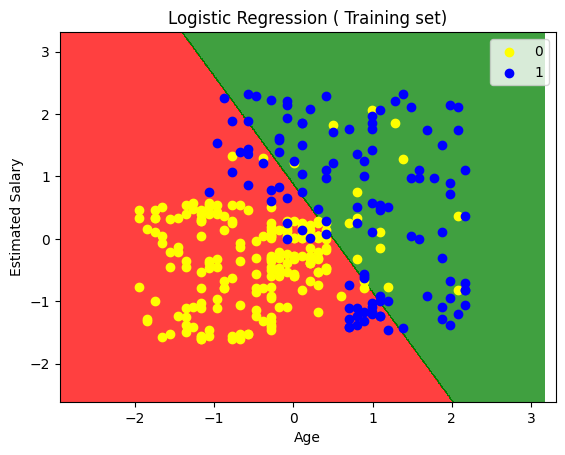

In [ ]:
# Visualising the Training set results
 
from matplotlib.colors import ListedColormap
X_Set, Y_Set = x_train, y_train

X1, X2 = np.meshgrid(
    np.arange(
        start=float(X_Set[:,0].min()) - 1,
        stop=float(X_Set[:,0].max()) + 1,
        step=0.01
    ),
    np.arange(
        start=float(X_Set[:,1].min()) - 1,
        stop=float(X_Set[:,1].max()) + 1,
        step=0.01
    )
)
 
plt.contourf(X1,X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
 
plt.xlim(X1.min(), X2.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_Set)):
    plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j,1],
                c = ListedColormap(('yellow', 'blue'))(i), label = j)
plt.title('Logistic Regression ( Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()
 
 